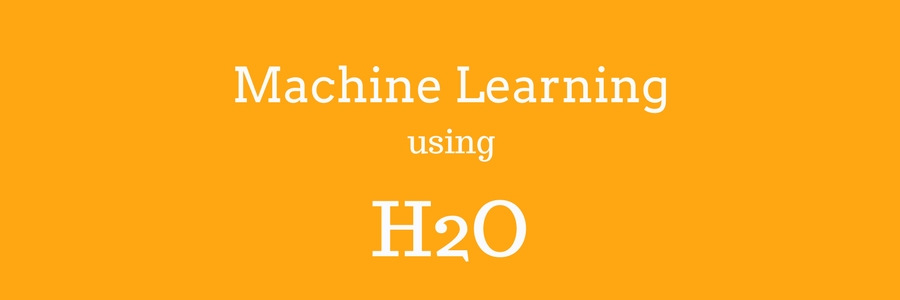

<a id="1.4"></a>
## <div style="box-shadow: rgba(0, 0, 0, 0.18) 0px 2px 4px inset; padding:20px; font-size:24px; font-family: consolas; text-align:center; display:fill; border-radius:15px; color:rgb(67, 66, 66)"> <b>  Refrences</b></div>

# The final Solution is devloped from this notebook (ensmble, with differnt weight)
# Thanks to each member for thier contribution 
# https://www.kaggle.com/code/vyacheslavbolotin/ps-s5-e4-ensemble-of-solutions
# https://www.kaggle.com/code/ayushchandramaurya/predicting-podcast-listening-time-ensemble
# https://www.kaggle.com/code/mikhailnaumov/podcast-nn-ydf-cat-xgb-lgbm-hgb
# https://www.kaggle.com/code/vasusoni/predict-podcast-ensemble

<div class="alert alert-success"> 
        <h1 align="center" style="color:chocolate;">Predict Podcast Listening Time
 
</h1>  
     
</div>

<p><center style="color:blue; font-family: 'Dancing Script'; font-size:30px;">🙏🏿Thanks for visiting my notebook 🕺🏿</center></p>

In [ ]:
import pandas as pd
import h2o
from h2o.automl import H2OAutoML
from itertools import combinations
from scipy.stats import gmean, hmean
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
h2o.init()

<div class="alert alert-success"> 
        <h1 align="center" style="color:chocolate;">Enter the Data world
</h1>  
     
</div>

In [ ]:
data_folder = "/kaggle/input/playground-series-s5e4"


In [ ]:
df_train = pd.read_csv('/kaggle/input/playground-series-s5e4/train.csv')
df_test  = pd.read_csv('/kaggle/input/playground-series-s5e4/test.csv')
df_sub = pd.read_csv('/kaggle/input/playground-series-s5e4/sample_submission.csv')

<div style="border-radius:10px; border:#DEB887 solid; padding: 15px; background-color: lightgrey; font-size:100%; text-align:left">

<h3 align="center"><font color='black'>💡 Evalaution Metric :</font></h3>
    
    
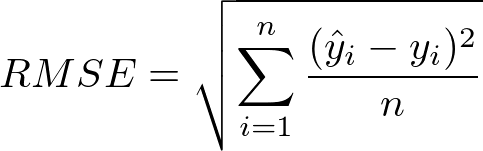
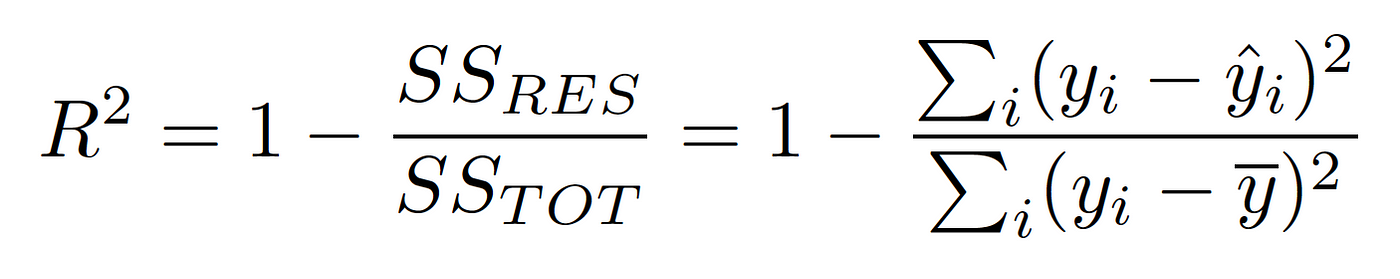

In [ ]:
df_train.shape

In [ ]:
df_train.shape

In [ ]:
df_train.drop(columns=['id'], inplace=True)
df_test.drop(columns=['id'], inplace=True)

In [ ]:
y = df_train['Listening_Time_minutes'] 
df_train = df_train.drop(['Listening_Time_minutes'],axis=1)

In [ ]:
df_train = pd.read_csv('/kaggle/input/interstellarspacetri/datap/train.csv')
df_test  = pd.read_csv('/kaggle/input/interstellarspacetri/datap/test.csv')

In [ ]:
df_train['Listening_Time_minutes'] = y

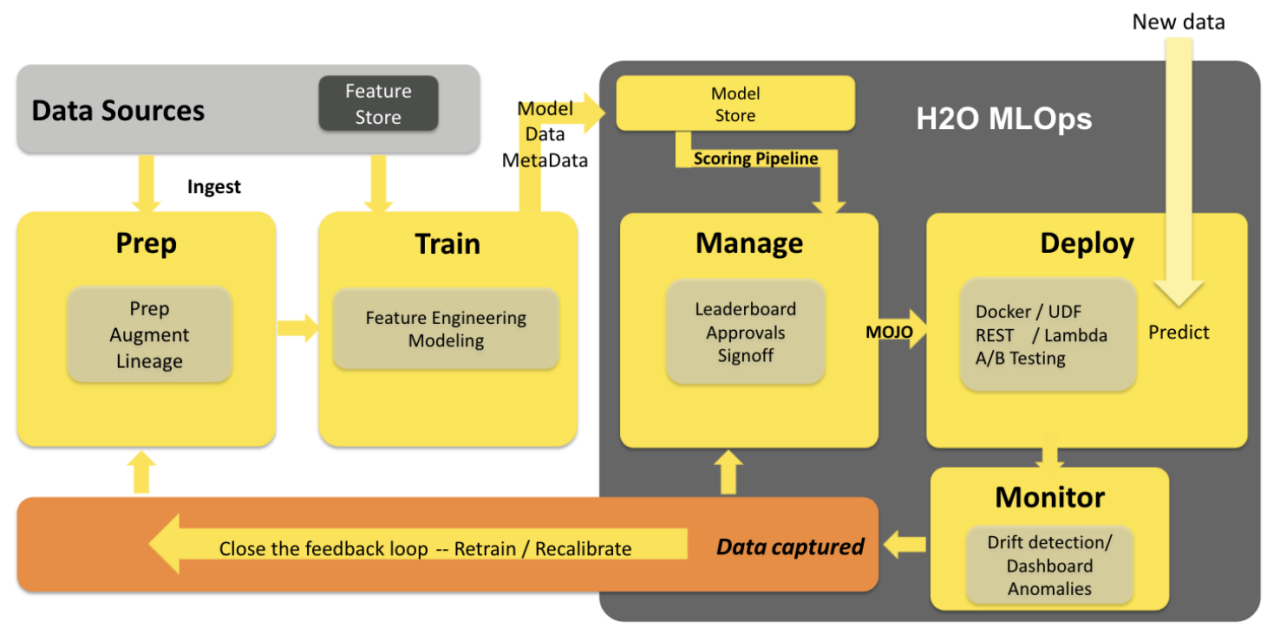

In [ ]:
train_data = h2o.H2OFrame(df_train)

In [ ]:
from h2o.frame import H2OFrame
with h2o.utils.threading.local_context(polars_enabled=True, datatable_enabled=True):
    pandas_df = train_data.as_data_frame()

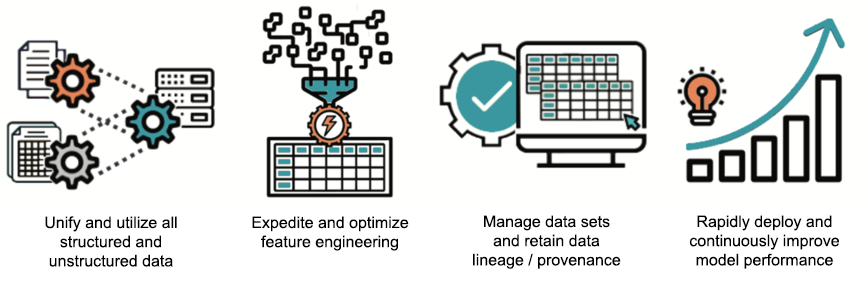

In [ ]:
train_data = h2o.H2OFrame(df_train)

In [ ]:
test_data = h2o.H2OFrame(df_test)

<div class="alert alert-success">  
    <h1 align="center" style="color:darkgoldenrod;">Training the Model</h1>  
     
</div>

In [ ]:
aml = H2OAutoML(max_runtime_secs=560, seed=42, sort_metric="RMSE",distribution="AUTO",nfolds=5)


In [ ]:
#aml = H2OAutoML(max_runtime_secs=590,seed=42)

#aml = H2OAutoML(max_runtime_secs=3000,nfolds=5,stopping_metric="rmse",
                #sort_metric="rmse",seed=69,max_models=20)
aml.train(y='Listening_Time_minutes', training_frame=train_data)

<div class="alert alert-success">  
    <h1 align="center" style="color:darkgoldenrod;">What Leadboard has to say</h1>  
     
</div>

In [ ]:
leaderboard = aml.leaderboard
print(leaderboard)
best_model = aml.leader
print(best_model)

In [ ]:
df_test = h2o.H2OFrame(df_test)

In [ ]:
predictions = best_model.predict(df_test)
predictions_df = predictions.as_data_frame()

# <span style="color:#E888BB; font-size: 1%;">1 | DATA CLEANSING AND DATA PREP</span>
<div style="padding: 35px;color:white;margin:10;font-size:170%;text-align:left;display:fill;border-radius:10px;overflow:hidden;background-image: url(https://images.pexels.com/photos/532173/pexels-photo-532173.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=1)"><b><span style='color:black'> Final Submission </span></b> </div>

In [ ]:
invisible = pd.read_csv('/kaggle/input/space-tour/81042.csv')
Ayush_chandra_Maurya   = pd.read_csv('/kaggle/input/space-tour/81649.csv')
Mikhail_Naumov = pd.read_csv('/kaggle/input/space-tour/8170.csv')
Vasu_Soni  = pd.read_csv('/kaggle/input/space-tour/82124.csv')

In [ ]:
df_sub['Listening_Time_minutes'] =(predictions_df['predict'].values)*0.15+invisible['Listening_Time_minutes']*0.25 +Ayush_chandra_Maurya['Listening_Time_minutes']*0.25+Mikhail_Naumov['Listening_Time_minutes']*0.25+Vasu_Soni['Listening_Time_minutes']*0.1

In [ ]:
df_sub.to_csv('submission.csv', index=False)

In [ ]:
df_sub.head()

<a id="1.4"></a>
## <div style="box-shadow: rgba(0, 0, 0, 0.18) 0px 2px 4px inset; padding:20px; font-size:24px; font-family: consolas; text-align:center; display:fill; border-radius:15px; color:rgb(67, 66, 66)"> <b>  Refrences</b></div>

# Refrences https://docs.h2o.ai/h2o/latest-stable/h2o-docs/automl.html


<div style="background-color: black; padding: 20px; border-radius: 10px; margin: 20px auto; max-width: 600px;">
    <center>
        <div style="background-color: white; padding: 20px; border-radius: 10px;">
            <b style="font-size: 24px; color: #ff6600;">👏😊 &nbsp; IF YOU FIND THIS HELPFUL, PLEASE UPVOTE! &nbsp; 💢👏</b>
            <div style="margin-top: 20px; font-size: 18px; color: black;">
                🥽🖥This took quite a bit of effort on my part, and while it might seem trivial, 🏆🏆receiving your appreciation means a lot to me! 😅🎃 Your upvotes inspire me to keep creating helpful content like this🖥🍱.                    
            </div>
        </div>
    </center>
</div>